# Local Wakeword Bootstrap (Qwen + Internal Engine)

이 노트북은 로컬에서 `넙죽아` wakeword 모델을 만들기 위한 실행 허브입니다.
4-Phase 흐름(런타임 고정 -> 데이터 -> 학습 -> 평가/릴리스)으로 구성되어 있습니다.
현재 기본 실행 모드는 **Phase 1** 입니다.

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)


def run(cmd: list[str], check: bool = False) -> int:
    print("$", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=PROJECT_ROOT, check=check)
    print("exit code:", proc.returncode)
    return proc.returncode


PROJECT_ROOT: /Users/unripeplum/projects/nubjuk/wakeword


## Phase 1) Runtime Lock + Baseline Snapshot

런타임 계약(입력/포맷)과 환경 의존성을 고정하고, 기존 학습 산출물의 최신 지표를 스냅샷으로 확인합니다.

In [2]:
import csv

strict = False
cmd = [sys.executable, "-m", "mcu_wakeword.cli", "check-env"]
if strict:
    cmd.append("--strict")
run(cmd, check=False)

print("\n[phase1] runtime contract (locked)")
runtime_contract = {
    "sample_rate_hz": 16000,
    "frame_hop_samples": 512,
    "frame_hop_ms": 32,
    "feature_bins": 40,
    "model_format": "tflite int8",
}
for key, value in runtime_contract.items():
    print(f"  - {key}: {value}")

print("\n[phase1] baseline artifacts snapshot")
history_files = sorted(
    (PROJECT_ROOT / "models").rglob("validation_history.csv"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if history_files:
    latest_history = history_files[0]
    print("  - latest validation_history:", latest_history)
    with latest_history.open("r", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    if rows:
        last = rows[-1]
        watch_keys = [
            "step",
            "accuracy",
            "recall",
            "precision",
            "auc",
            "average_viable_recall",
            "recall_at_no_faph",
            "false_accepts_per_hour",
        ]
        print("  - latest metrics:")
        for key in watch_keys:
            if key in last and str(last[key]).strip() != "":
                print(f"      {key}: {last[key]}")
    else:
        print("  - validation_history.csv is empty")
else:
    print("  - no validation_history.csv found under models/")

release_models = sorted(
    (PROJECT_ROOT / "models").rglob("wake_nubjuk_ko.tflite"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if release_models:
    print("  - latest release model:", release_models[0])
else:
    print("  - release model not found yet")


$ /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli check-env
[check-env] validating local environment
  - python_version   OK       3.10.20 (recommended: 3.10~3.12)
  - tensorflow       OK       tensorflow import availability
  - wakeword_engine  OK       internal wakeword engine package import availability
  - qwen_tts         OK       qwen-tts package import availability
  - torch            OK       torch import availability
  - soundfile        OK       soundfile import availability
exit code: 0

[phase1] runtime contract (locked)
  - sample_rate_hz: 16000
  - frame_hop_samples: 512
  - frame_hop_ms: 32
  - feature_bins: 40
  - model_format: tflite int8

[phase1] baseline artifacts snapshot
  - latest validation_history: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260428_235512/data/metrics/validation_history.csv
  - latest metrics:
  - latest release model: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/release/wake

## Phase 2) Korean Wakeword Synthesis (Qwen)

한국어 텍스트를 그대로 넣어 샘플을 생성하고, QC를 통과한 파일만 `generated_samples/`에 남깁니다.

In [4]:
from datetime import datetime

from mcu_wakeword.pipeline_config import load_pipeline_config
from mcu_wakeword.target_config_map import resolve_target_config

target_word = "넙죽아"
target_slug_override = None
target_map_path = PROJECT_ROOT / "configs" / "target_word_map.yaml"
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

# Local dataset presets (LiveKit data philosophy 기반)
livekit_sample_profile = "serious_local"
livekit_sample_profiles = {
    "smoke": {"positive": 100, "adversarial": 20, "source": "quick sanity"},
    "serious_local": {"positive": 1200, "adversarial": 400, "source": "local full train"},
    "heavy_local": {"positive": 3000, "adversarial": 1000, "source": "long run"},
}
assert livekit_sample_profile in livekit_sample_profiles, (
    f"Unknown livekit_sample_profile: {livekit_sample_profile}. "
    f"Choose one of {list(livekit_sample_profiles)}"
)
bulk_samples = int(livekit_sample_profiles[livekit_sample_profile]["positive"])
adversarial_samples = int(livekit_sample_profiles[livekit_sample_profile]["adversarial"])
batch_size = 8
# 주의: True + force=True면 config 파일이 기본값으로 덮어써집니다.
run_ensure_config = False
force_ensure_config = False

resolved_target = resolve_target_config(
    target_word=target_word,
    target_slug_override=target_slug_override,
    map_path=target_map_path,
    project_root=PROJECT_ROOT,
)
config_path = resolved_target.config_path
target_slug = resolved_target.target_slug
model_name = resolved_target.model_name

ensure_cfg_cmd = [
    sys.executable,
    "-m",
    "mcu_wakeword.cli",
    "resolve-config",
    "--target-word",
    target_word,
    "--map-path",
    str(target_map_path),
    "--run-id",
    run_id,
]
if target_slug_override:
    ensure_cfg_cmd.extend(["--target-slug", target_slug_override])
if run_ensure_config:
    ensure_cfg_cmd.append("--ensure-config")
    if force_ensure_config:
        ensure_cfg_cmd.append("--force")

print("CONFIG MAP:", target_map_path)
print("CONFIG RESOLVE:", " ".join(ensure_cfg_cmd))
if run_ensure_config:
    run(ensure_cfg_cmd, check=False)
else:
    print("CONFIG RESOLVE 실행을 건너뜁니다. 기존 config를 그대로 사용합니다.")

assert config_path.exists(), f"Config file not found: {config_path}"
cfg = load_pipeline_config(config_path)
target_slug = cfg.layout.target_slug
model_name = cfg.model_name

datasets_root = Path(cfg.layout.datasets_dir) / target_slug
features_root = Path(cfg.layout.features_dir) / target_slug
models_root = Path(cfg.layout.models_dir) / target_slug
training_root = Path(cfg.layout.training_dir) / target_slug / "wakeword"

preview_dir = datasets_root / "preview_sample" / run_id / "data"
generated_dir = Path(cfg.synth.output_dir)
generated_adversarial_dir = Path(cfg.synth.adversarial_output_dir)
near_miss_candidates_file = generated_adversarial_dir / "near_miss_candidates.txt"
near_miss_approved_file = generated_adversarial_dir / "near_miss_approved.txt"
near_miss_min_approved = int(getattr(cfg.synth, "near_miss_min_approved", 8))
near_miss_phrases_from_config = list(getattr(cfg.synth, "near_miss_phrases", []))
if not near_miss_phrases_from_config:
    near_miss_phrases_from_config = list(getattr(cfg.synth, "adversarial_phrase", []))
negative_audio_data_dir = Path(cfg.eval.negatives).parent
holdout_positive_dir = Path(cfg.eval.positives)

positive_features_dir = Path(cfg.train.positive_features_dir)
negative_features_root = Path(cfg.train.negative_features_root)

train_dir = Path(cfg.train.train_dir)
train_log_root = train_dir / "logs"
train_model_tflite = Path(cfg.eval.model)
training_yaml = Path(cfg.train.training_yaml)
release_model_path = Path(cfg.export.release_path)

for d in [
    preview_dir,
    generated_dir,
    generated_adversarial_dir,
    holdout_positive_dir,
    positive_features_dir,
    negative_features_root,
    train_dir,
    training_yaml.parent,
    release_model_path.parent,
]:
    d.mkdir(parents=True, exist_ok=True)

instructs = [
    "차분한 한국어 여성 목소리, 또렷한 발음",
    "부드러운 한국어 남성 목소리, 중간 속도",
    "밝고 경쾌한 톤, 자연스러운 한국어 발화",
    "조용한 환경에서 또렷하게 말하는 톤",
]

print("target_word:", target_word)
print("target_slug:", target_slug)
print("model_name:", model_name)
print("run_id:", run_id)
print("config_path:", config_path)
print("livekit_sample_profile:", livekit_sample_profile)
print("livekit_source:", livekit_sample_profiles[livekit_sample_profile]["source"])
print("bulk_samples:", bulk_samples)
print("adversarial_samples:", adversarial_samples)
print("near_miss_candidates_file:", near_miss_candidates_file)
print("near_miss_approved_file:", near_miss_approved_file)
print("near_miss_min_approved:", near_miss_min_approved)
print("near_miss_phrases_from_config:", near_miss_phrases_from_config)
print("batch_size:", batch_size)
print("preview_dir:", preview_dir)
print("generated_dir:", generated_dir)
print("train_dir:", train_dir)
print("training_yaml:", training_yaml)
print("release_model_path:", release_model_path)


CONFIG MAP: /Users/unripeplum/projects/nubjuk/wakeword/configs/target_word_map.yaml
CONFIG RESOLVE: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli resolve-config --target-word 넙죽아 --map-path /Users/unripeplum/projects/nubjuk/wakeword/configs/target_word_map.yaml --run-id 20260429_032940
CONFIG RESOLVE 실행을 건너뜁니다. 기존 config를 그대로 사용합니다.
target_word: 넙죽아
target_slug: neopjuka
model_name: wake_nubjuk_ko
run_id: 20260429_032940
config_path: /Users/unripeplum/projects/nubjuk/wakeword/configs/nubjuk_pipeline.yaml
livekit_sample_profile: serious_local
livekit_source: local full train
bulk_samples: 1200
adversarial_samples: 400
near_miss_candidates_file: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_candidates.txt
near_miss_approved_file: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_approved.txt
near_miss_min_approved: 8
near_mi

### 2.1) Single Sample Preview

테스트용 샘플 1개를 실제로 생성하고 바로 들어봅니다.
(`synth --dry-run` 과 별개로 동작)


In [4]:
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

run_preview_sample = True
preview_samples = 1
preview_min_rms_for_check = 0.003

preview_dir.mkdir(parents=True, exist_ok=True)
preview_cmd = [
    sys.executable,
    "-m",
    "mcu_wakeword.cli",
    "synth",
    "--target-word",
    target_word,
    "--max-samples",
    str(preview_samples),
    "--batch-size",
    "1",
    "--output-dir",
    str(preview_dir),
    "--device",
    "cpu",
    "--dtype",
    "float32",
    "--clean-output",
    "--qc-min-rms",
    str(preview_min_rms_for_check),
    "--no-generate-adversarial",
    "--adversarial-max-samples",
    "0",
]
for instr in instructs:
    preview_cmd.extend(["--instruct", instr])

print("PREVIEW:", " ".join(preview_cmd))
if run_preview_sample:
    run(preview_cmd, check=False)
else:
    print("run_preview_sample=False 이므로 새 미리듣기 생성을 건너뜁니다.")

def _wav_stats(path):
    arr, sr = sf.read(path, always_2d=False)
    x = np.asarray(arr, dtype=np.float32).reshape(-1)
    rms = float(np.sqrt(np.mean(x * x))) if len(x) else 0.0
    peak = float(np.max(np.abs(x))) if len(x) else 0.0
    dur = float(len(x) / sr) if sr else 0.0
    return {"path": path, "sr": sr, "dur": dur, "rms": rms, "peak": peak}

preview_wavs = sorted(preview_dir.glob("*.wav"), key=lambda p: p.stat().st_mtime, reverse=True)
if not preview_wavs:
    raw_wavs = sorted((preview_dir / "_raw_qwen").glob("*.wav"), key=lambda p: p.stat().st_mtime, reverse=True)
    if raw_wavs:
        print("QC 통과본이 없어 raw 샘플을 확인합니다.")
        preview_wavs = raw_wavs

if preview_wavs:
    p = preview_wavs[0]
    s = _wav_stats(p)
    print("Preview wav:", p)
    print(f"stats: dur={s['dur']:.2f}s sr={s['sr']} rms={s['rms']:.6f} peak={s['peak']:.6f}")
    if s['rms'] < preview_min_rms_for_check:
        print("WARNING: RMS가 매우 낮습니다. 체감상 무음일 수 있습니다.")
    display(Audio(filename=str(p), autoplay=False))
else:
    raw_wavs = sorted((preview_dir / "_raw_qwen").glob("*.wav"), key=lambda p: p.stat().st_mtime, reverse=True)
    if raw_wavs:
        raw = raw_wavs[0]
        s = _wav_stats(raw)
        print("No QC-passed preview wav found. raw 샘플 통계를 확인하세요:")
        print("raw wav:", raw)
        print(f"raw stats: dur={s['dur']:.2f}s sr={s['sr']} rms={s['rms']:.6f} peak={s['peak']:.6f}")
        display(Audio(filename=str(raw), autoplay=False))
    else:
        print(f"No preview wav found in: {preview_dir}")


PREVIEW: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli synth --target-word 넙죽아 --max-samples 1 --batch-size 1 --output-dir /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data --device cpu --dtype float32 --clean-output --qc-min-rms 0.003 --no-generate-adversarial --adversarial-max-samples 0 --instruct 차분한 한국어 여성 목소리, 또렷한 발음 --instruct 부드러운 한국어 남성 목소리, 중간 속도 --instruct 밝고 경쾌한 톤, 자연스러운 한국어 발화 --instruct 조용한 환경에서 또렷하게 말하는 톤
$ /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli synth --target-word 넙죽아 --max-samples 1 --batch-size 1 --output-dir /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data --device cpu --dtype float32 --clean-output --qc-min-rms 0.003 --no-generate-adversarial --adversarial-max-samples 0 --instruct 차분한 한국어 여성 목소리, 또렷한 발음 --instruct 부드러운 한국어 남성 목소리, 중간 속도 --instruct 밝고 경쾌한 톤, 자연스러운 한국어 발화 --instruct 조용한 환경에서 또렷하게 말하는 톤

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 42153.81it/s]


[synth] generation start: new_samples=1 target_samples=1 batch_size=1 total_batches=1
[synth] generating batch 1/1 (batch_items=1)


Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


[synth] batch 1/1 complete: generated_so_far=1
[synth] raw generated: 1 files -> /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data/_raw_qwen (raw_dir_wav_count=1)
[synth] quality gate kept 1/1 files
[synth] quality gate dropped 0 files
[synth] final_wav_count=1 in /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data
[synth] qc manifest: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data/qwen_qc_manifest.csv
exit code: 0
Preview wav: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/preview_sample/20260429_011611/data/000000.wav
stats: dur=1.84s sr=16000 rms=0.054135 peak=0.344452


### 2.2) Near-miss Review

이 셀에서 near-miss 후보/승인 파일을 확인하고, 승인 단어를 확정합니다.
- near-miss 후보: `near_miss_candidates_file`
- near-miss 승인: `near_miss_approved_file`

실제 대량 생성은 아래 `2.3) Bulk Synthesis Run` 셀에서 실행합니다.


In [5]:
from mcu_wakeword.qwen_synth import build_adversarial_phrases

run_near_miss_review = True

# near-miss는 config(synth.near_miss_phrases)에서 읽습니다.
manual_near_miss_phrases = [str(x).strip() for x in near_miss_phrases_from_config if str(x).strip()]
use_manual_near_miss = len(manual_near_miss_phrases) > 0

near_miss_candidates = []
approved_preview = []
effective_min_approved = near_miss_min_approved

if run_near_miss_review:
    if use_manual_near_miss:
        seen = set()
        near_miss_candidates = []
        for raw in manual_near_miss_phrases:
            t = str(raw).strip()
            if not t or t in seen:
                continue
            near_miss_candidates.append(t)
            seen.add(t)
        effective_min_approved = max(1, len(near_miss_candidates))
    else:
        near_miss_candidates = build_adversarial_phrases(
            target_phrases=[target_word],
            custom_phrases=("넌죽아", "넙넙아"),
            language="Korean",
        )

    near_miss_candidates_file.parent.mkdir(parents=True, exist_ok=True)
    with near_miss_candidates_file.open("w", encoding="utf-8") as f:
        f.write(f"# near-miss candidates for {target_word}\n")
        f.write("# Copy reviewed phrases into near_miss_approved_file and rerun.\n")
        for p in near_miss_candidates:
            f.write(p + "\n")

    if use_manual_near_miss:
        with near_miss_approved_file.open("w", encoding="utf-8") as f:
            f.write("# manual near-miss approved list\n")
            for p in near_miss_candidates:
                f.write(p + "\n")
    elif not near_miss_approved_file.exists():
        with near_miss_approved_file.open("w", encoding="utf-8") as f:
            f.write("# reviewed near-miss phrases only (one per line)\n")
            f.write("넌죽아\n")
            f.write("넙넙아\n")

    for line in near_miss_approved_file.read_text(encoding="utf-8").splitlines():
        t = line.strip()
        if not t or t.startswith("#"):
            continue
        approved_preview.append(t)

print("use_manual_near_miss:", use_manual_near_miss)
print("near_miss_candidates:", len(near_miss_candidates), near_miss_candidates_file)
print("near_miss_approved:", len(approved_preview), near_miss_approved_file)
print("near_miss_candidates_preview:", near_miss_candidates[:30])
print("near_miss_approved_preview:", approved_preview[:30])
print("effective_min_approved:", effective_min_approved)
if len(approved_preview) < effective_min_approved:
    print(
        f"WARNING: approved near-miss 개수({len(approved_preview)})가 최소값({effective_min_approved})보다 작습니다. "
        "approved 파일을 수정한 뒤 셀을 다시 실행하세요."
    )


use_manual_near_miss: True
near_miss_candidates: 8 /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_candidates.txt
near_miss_approved: 8 /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_approved.txt
near_miss_candidates_preview: ['멍죽아', '넙넙아', '넌넌아', '넙직아', '겁죽아', '너죽아', '죽넙아', '넙아죽']
near_miss_approved_preview: ['멍죽아', '넙넙아', '넌넌아', '넙직아', '겁죽아', '너죽아', '죽넙아', '넙아죽']
effective_min_approved: 8


### 2.3) Bulk Synthesis Run

2.2 셀에서 near-miss 승인 내용을 확인한 다음, 이 셀에서 실제 대량 생성을 실행합니다.

In [11]:
run_bulk_synth = True  # near-miss 승인 확인 후 True로 변경
manual_near_miss_phrases = globals().get(
    "manual_near_miss_phrases",
    [str(x).strip() for x in near_miss_phrases_from_config if str(x).strip()],
)
effective_min_approved = globals().get("effective_min_approved", max(1, len(manual_near_miss_phrases)) if manual_near_miss_phrases else near_miss_min_approved)

bulk_cmd = [
    sys.executable,
    "-m",
    "mcu_wakeword.cli",
    "synth",
    "--target-word",
    target_word,
    "--model-id",
    "Qwen/Qwen3-TTS-12Hz-1.7B-VoiceDesign",
    "--language",
    "Korean",
    "--max-samples",
    str(bulk_samples),
    "--adversarial-max-samples",
    str(adversarial_samples),
    "--batch-size",
    str(batch_size),
    "--output-dir",
    str(generated_dir),
    "--adversarial-output-dir",
    str(generated_adversarial_dir),
    "--near-miss-review-required",
    "--near-miss-candidates-file",
    str(near_miss_candidates_file),
    "--near-miss-approved-file",
    str(near_miss_approved_file),
    "--near-miss-use-approved-only",
    "--near-miss-min-approved",
    str(effective_min_approved),
    "--device",
    "cpu",
    "--dtype",
    "float32",
    "--clean-output",
]
for instr in instructs:
    bulk_cmd.extend(["--instruct", instr])
for phrase in manual_near_miss_phrases:
    bulk_cmd.extend(["--near-miss-phrase", phrase])

print("BULK SYNTH:", " ".join(bulk_cmd))
bulk_rc = 0
if run_bulk_synth:
    bulk_rc = run(bulk_cmd, check=False)
else:
    print("run_bulk_synth=False 이므로 실제 데이터셋 대량 생성을 건너뜁니다.")

if bulk_rc != 0:
    print("near-miss 승인 파일을 확인한 뒤 다시 실행하세요:")
    print(" - candidates:", near_miss_candidates_file)
    print(" - approved:", near_miss_approved_file)

generated_root = len(list(generated_dir.glob("*.wav")))
generated_recursive = len(list(generated_dir.rglob("*.wav")))
generated_raw_qwen = len(list((generated_dir / "_raw_qwen").glob("*.wav")))
generated_adv_root = len(list(generated_adversarial_dir.glob("*.wav")))
generated_adv_recursive = len(list(generated_adversarial_dir.rglob("*.wav")))
print("generated final wav (root):", generated_root)
print("generated raw_qwen wav:", generated_raw_qwen)
print("generated recursive wav:", generated_recursive)
print("generated adversarial wav (root):", generated_adv_root)
print("generated adversarial recursive wav:", generated_adv_recursive)
if generated_root < 10:
    print("WARNING: 최종 학습용 wav(root, QC 통과본) 개수가 10개 미만입니다. synth 셀을 다시 실행하세요.")


BULK SYNTH: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli synth --target-word 넙죽아 --model-id Qwen/Qwen3-TTS-12Hz-1.7B-VoiceDesign --language Korean --max-samples 1200 --adversarial-max-samples 400 --batch-size 8 --output-dir /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_samples/20260429_011002/data --adversarial-output-dir /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data --near-miss-review-required --near-miss-candidates-file /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_candidates.txt --near-miss-approved-file /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/near_miss_approved.txt --near-miss-use-approved-only --near-miss-min-approved 8 --device cpu --dtype float32 --clean-output --instruct 차분한 한국어 여성 목소리, 또렷한 발음 --instruct 부드러운 한국어 남성 목소리, 중간 속도 --ins

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 48629.61it/s]


[synth] generation start: new_samples=1200 target_samples=1200 batch_size=8 total_batches=150
[synth] generating batch 1/150 (batch_items=8)


Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


[synth] batch 1/150 complete: generated_so_far=8
[synth] generating batch 2/150 (batch_items=8)


...

[synth] batch 48/50 complete: generated_so_far=384
[synth] generating batch 49/50 (batch_items=8)


Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


[synth] batch 49/50 complete: generated_so_far=392
[synth] generating batch 50/50 (batch_items=8)


Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2150 for open-end generation.


[synth] batch 50/50 complete: generated_so_far=400
[synth] adversarial raw generated: 400 files -> /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/_raw_qwen (raw_dir_wav_count=400)
[synth] adversarial quality gate kept 375/400 files
[synth] adversarial quality gate dropped 25 files
[synth] adversarial final_wav_count=375 in /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data
[synth] adversarial qc manifest: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_adversarial/20260429_011002/data/qwen_qc_manifest.csv
exit code: 0
generated final wav (root): 1141
generated raw_qwen wav: 1200
generated recursive wav: 2341
generated adversarial wav (root): 375
generated adversarial recursive wav: 775


## Phase 3) Train + Learning Curves

학습을 실행하고, 같은 셀에서 TensorBoard 로그 기반 학습 곡선을 바로 확인합니다.


[phase3] run_train=True, show_training_curves=True
[phase3] positive wav source: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_samples/20260429_011002/data (wav=1141)
[phase3] training_steps=40000
background audio dirs found: 0
rir dirs found: 0
TRAIN: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli train --training-steps 40000 --training-yaml /Users/unripeplum/projects/nubjuk/wakeword/training/neopjuka/wakeword/20260429_011002/data/training_parameters.yaml --positive-features-dir /Users/unripeplum/projects/nubjuk/wakeword/features/neopjuka/generated_augmented_features/20260429_011002/data --negative-features-root /Users/unripeplum/projects/nubjuk/wakeword/features/neopjuka/negative_datasets/20260429_011002/data --train-dir /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data --prepare-positive-wavs /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_samples/20260429_011002/data

INFO:absl:Loading and analyzing data sets.
INFO:absl:None


Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (128, 204, 40)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼───��────────┼───────────────────┤
│ expand_dims         │ (128, 204, 1, 40) │          0 │ input_layer[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stream (Stream)     │ (128, 67, 1, 32)  │      6,400 │ expand_dims[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (128, 67, 1, 32)  │          0 │ stream[0][0]      │
│ (Activation)        │                   │            

INFO:absl:Step #500: rate 0.001000, accuracy 99.79%, recall 97.39%, precision 99.81%, cross entropy 0.005990
INFO:absl:Step 500 (nonstreaming): Validation: recall at no faph = 0.000 with cutoff 1.00, accuracy = 96.88%, recall = 96.88%, precision = 100.00%, ambient false positives = 12, estimated false positives per hour = 1.24089, loss = 0.01405, auc = 0.99511, average viable recall = 0.941560012
INFO:absl:Sharding callback duration: 11 microseconds
INFO:absl:So far the best minimization quantity is 0.000 with best maximization quantity of 94.15600%; no faph cutoff is 1.00
INFO:absl:Validation history saved: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_history.csv (entries=1)
INFO:absl:Validation curves updated: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_curves.png


INFO:absl:Step #1000: rate 0.001000, accuracy 99.76%, recall 97.40%, precision 99.41%, cross entropy 0.007227
INFO:absl:Step 1000 (nonstreaming): Validation: recall at no faph = 0.000 with cutoff 1.00, accuracy = 97.65%, recall = 97.65%, precision = 100.00%, ambient false positives = 202, estimated false positives per hour = 20.88832, loss = 0.01206, auc = 0.99931, average viable recall = 0.666688510
INFO:absl:So far the best minimization quantity is 0.000 with best maximization quantity of 94.15600%; no faph cutoff is 1.00
INFO:absl:Validation history saved: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_history.csv (entries=2)
INFO:absl:Validation curves updated: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_curves.png


...

Model: "functional_1"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (1, 204, 40)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼───��────────┼───────────────────┤
│ expand_dims_1       │ (1, 204, 1, 40)   │          0 │ input_layer_1[0]… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stream_6 (Stream)   │ (1, 67, 1, 32)    │      6,400 │ expand_dims_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (1, 67, 1, 32)    │          0 │ stream_6[0][0]    │
│ (Activation)        │                   │          

INFO:absl:Function `call` contains input name(s) resource with unsupported characters which will be renamed to dense_1_1_add_readvariableop_resource in the SavedModel.
INFO:absl:Function `call` contains input name(s) resource with unsupported characters which will be renamed to dense_1_1_add_readvariableop_resource in the SavedModel.
INFO:absl:Sharding callback duration: 12 microseconds
INFO:absl:Sharding callback duration: 10 microseconds
INFO:absl:Writing fingerprint to /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/stream_state_internal/fingerprint.pb
INFO:absl:Converting quantized streaming model to TFLite


Saved artifact at '/Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/stream_state_internal'. The following endpoints are available:

* Endpoint 'serve'
  inputs (POSITIONAL_OR_KEYWORD): TensorSpec(shape=(1, 3, 40), dtype=tf.float32, name=None)
  training (POSITIONAL_OR_KEYWORD): Literal[None]
  mask (POSITIONAL_OR_KEYWORD): Literal[None]
Output Type:
  TensorSpec(shape=(1, 1), dtype=tf.float32, name=None)
Captures:
  6054506944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6063467760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054496384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054306112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054300304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054309104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054308576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054308048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6054505536: TensorSpec(

W0000 00:00:1777401641.186377 6520630 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777401641.186388 6520630 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: UINT8
W0000 00:00:1777401648.952821 6520630 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
INFO:absl:Testing the TFLite quantized streaming model false accept per hour and false rejection rates at various cutoffs.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO:absl:Testing the testing_ambient set.
INFO:absl:Testing the testing set.
INFO:absl:AUC 0.00160
INFO:absl:Cutoff 0.98: frr=0.0085; faph=0.000
INFO:absl:Cutoff 0.90: frr=0.0043; faph=0.187
INFO:absl:Cutoff 0.28: frr=0.0000; faph=0.375
INFO:absl:Cutoff 0.09: frr=0.0000; faph=0.562
INFO:absl:Cutoff 0.07: frr=0.0000; faph=0.750
INFO:absl:Cutoff 0.06: frr=0.0000; faph=0.9

[train] exit_code=0
[train] validation history csv: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_history.csv
[train] validation curves png: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/metrics/validation_curves.png
exit code: 0
[phase3] train logdir: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/logs/train
[phase3] val logdir: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/logs/validation


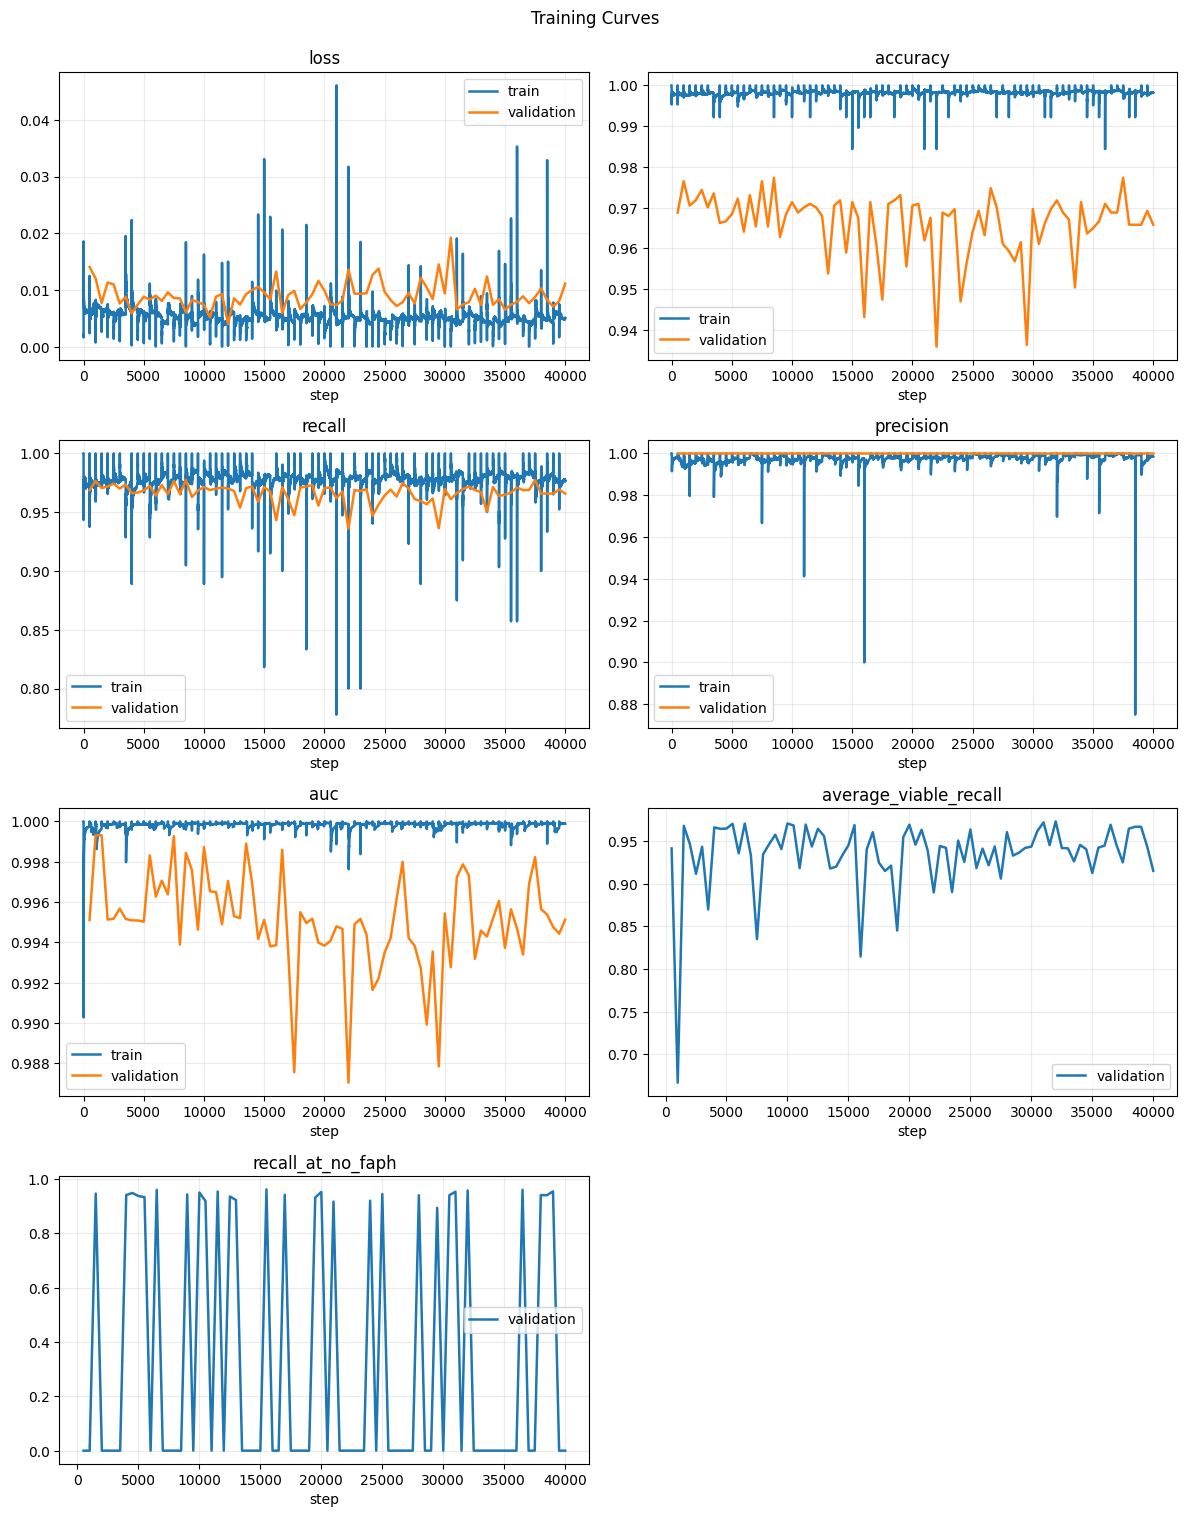

In [5]:
run_train = True
show_training_curves = True
print(f"[phase3] run_train={run_train}, show_training_curves={show_training_curves}")
if not run_train:
    print("[phase3] 학습이 비활성화되었습니다. run_train=True로 변경하세요.")
if "run" not in globals():
    import subprocess

    def run(cmd: list[str], check: bool = False) -> int:
        print("$", " ".join(cmd))
        proc = subprocess.run(cmd, cwd=PROJECT_ROOT, check=check)
        print("exit code:", proc.returncode)
        return proc.returncode

if "generated_dir" not in globals():
    if "Path" not in globals():
        from pathlib import Path

    print("[phase3] bootstrap context missing -> reloading from config")
    from mcu_wakeword.pipeline_config import load_pipeline_config
    from mcu_wakeword.target_config_map import resolve_target_config

    if "PROJECT_ROOT" not in globals():
        cwd = Path.cwd().resolve()
        PROJECT_ROOT = None
        for candidate in [cwd, *cwd.parents]:
            if (candidate / "pyproject.toml").exists():
                PROJECT_ROOT = candidate
                break
        if PROJECT_ROOT is None:
            PROJECT_ROOT = cwd
    if "target_word" not in globals():
        target_word = "넙죽아"
    if "target_slug_override" not in globals():
        target_slug_override = None
    if "target_map_path" not in globals() or not Path(target_map_path).exists():
        target_map_path = PROJECT_ROOT / "configs" / "target_word_map.yaml"
    else:
        target_map_path = Path(target_map_path)

    resolved_target = resolve_target_config(
        target_word=target_word,
        target_slug_override=target_slug_override,
        map_path=target_map_path,
        project_root=PROJECT_ROOT,
    )
    cfg = load_pipeline_config(resolved_target.config_path)
    target_slug = cfg.layout.target_slug
    datasets_root = Path(cfg.layout.datasets_dir) / target_slug
    models_root = Path(cfg.layout.models_dir) / target_slug
    generated_dir = Path(cfg.synth.output_dir)
    positive_features_dir = Path(cfg.train.positive_features_dir)
    negative_features_root = Path(cfg.train.negative_features_root)
    train_dir = Path(cfg.train.train_dir)
    train_log_root = train_dir / "logs"
    training_yaml = Path(cfg.train.training_yaml)

selected_positive_wavs = generated_dir
if next(selected_positive_wavs.glob("*.wav"), None) is None:
    candidates = []
    for d in (datasets_root / "generated_samples").glob("*/data"):
        if not d.is_dir():
            continue
        wav_count = sum(1 for _ in d.glob("*.wav"))
        if wav_count <= 0:
            continue
        candidates.append((d.stat().st_mtime, wav_count, d))
    if candidates:
        candidates.sort(reverse=True)
        _, wav_count, latest_dir = candidates[0]
        selected_positive_wavs = latest_dir
        print(f"[phase3] generated_dir 비어 있음 -> 최신 데이터셋 사용: {latest_dir} (wav={wav_count})")
    else:
        print(f"[phase3] 경고: generated_samples 아래에 wav 데이터셋이 없습니다: {datasets_root / 'generated_samples'}")
else:
    wav_count = sum(1 for _ in selected_positive_wavs.glob("*.wav"))
    print(f"[phase3] positive wav source: {selected_positive_wavs} (wav={wav_count})")

available_bg_dirs = []
for p in sorted((datasets_root / "negative_audio").rglob("*")):
    if not p.is_dir():
        continue
    if p.name not in {"fma_16k", "audioset_16k", "dinner_party", "no_speech"}:
        continue
    if next(p.rglob("*.wav"), None) is None:
        continue
    available_bg_dirs.append(p)

available_rir_dirs = []
for p in sorted((datasets_root / "negative_audio").rglob("mit_rirs")):
    if not p.is_dir():
        continue
    if next(p.rglob("*.wav"), None) is None:
        continue
    available_rir_dirs.append(p)

training_steps = int(getattr(cfg.train, "training_steps", 40000))
print(f"[phase3] training_steps={training_steps}")

if "sys" not in globals():
    import sys

train_cmd = [
    sys.executable,
    "-m",
    "mcu_wakeword.cli",
    "train",
    "--training-steps",
    str(training_steps),
    "--training-yaml",
    str(training_yaml),
    "--positive-features-dir",
    str(positive_features_dir),
    "--negative-features-root",
    str(negative_features_root),
    "--train-dir",
    str(train_dir),
    "--prepare-positive-wavs",
    str(selected_positive_wavs),
]

for p in available_bg_dirs:
    train_cmd.extend(["--prepare-background-audio-dir", str(p)])

for p in available_rir_dirs:
    train_cmd.extend(["--prepare-rir-dir", str(p)])

print("background audio dirs found:", len(available_bg_dirs))
for p in available_bg_dirs[:6]:
    print("  bg:", p)
if len(available_bg_dirs) > 6:
    print("  ...")

print("rir dirs found:", len(available_rir_dirs))
for p in available_rir_dirs[:6]:
    print("  rir:", p)
if len(available_rir_dirs) > 6:
    print("  ...")
print("TRAIN:", " ".join(train_cmd))
print("(feature가 비어 있으면 train 내부에서 자동 prepare를 먼저 실행합니다)")

train_exit_code = None
if run_train:
    train_exit_code = run(train_cmd, check=False)
else:
    print("run_train=False 이므로 학습을 실행하지 않았습니다. True로 바꿔 실행하세요.")

if show_training_curves:
    try:
        import math

        import matplotlib.pyplot as plt
        import numpy as np
        import tensorflow as tf
        from tensorboard.backend.event_processing import event_accumulator
    except Exception as exc:
        print("Could not import plotting dependencies:", exc)
    else:
        train_logdir = train_log_root / "train"
        val_logdir = train_log_root / "validation"

        def has_tb_events(logdir):
            if not logdir.exists():
                return False
            return any(p.name.startswith("events.out.tfevents") for p in logdir.rglob("*"))

        if not has_tb_events(train_logdir) or not has_tb_events(val_logdir):
            fallback_runs = sorted(
                (models_root / "train").glob("*/data/logs"),
                key=lambda p: p.stat().st_mtime,
                reverse=True,
            )
            for logs_root in fallback_runs:
                cand_train = logs_root / "train"
                cand_val = logs_root / "validation"
                if has_tb_events(cand_train) and has_tb_events(cand_val):
                    if cand_train != train_logdir or cand_val != val_logdir:
                        print(f"[phase3] 현재 run 로그가 비어 있어 최근 로그로 fallback: {logs_root}")
                    train_logdir, val_logdir = cand_train, cand_val
                    break

        def load_tb_series(logdir):
            if not logdir.exists():
                return {}
            acc = event_accumulator.EventAccumulator(
                str(logdir),
                size_guidance={
                    event_accumulator.SCALARS: 0,
                    event_accumulator.TENSORS: 0,
                },
            )
            acc.Reload()
            tags = acc.Tags()
            all_tags = list(tags.get("scalars", [])) + list(tags.get("tensors", []))

            out = {}
            for tag in all_tags:
                by_step = {}

                if tag in tags.get("scalars", []):
                    for ev in acc.Scalars(tag):
                        by_step[int(ev.step)] = (float(ev.wall_time), float(ev.value))

                if tag in tags.get("tensors", []):
                    for ev in acc.Tensors(tag):
                        arr = tf.make_ndarray(ev.tensor_proto)
                        value = float(np.asarray(arr).reshape(-1)[0])
                        step = int(ev.step)
                        wall_time = float(ev.wall_time)
                        prev = by_step.get(step)
                        if prev is None or wall_time >= prev[0]:
                            by_step[step] = (wall_time, value)

                if by_step:
                    out[tag] = [(step, by_step[step][1]) for step in sorted(by_step)]

            return out

        print("[phase3] train logdir:", train_logdir)
        print("[phase3] val logdir:", val_logdir)

        train_series = load_tb_series(train_logdir)
        val_series = load_tb_series(val_logdir)

        preferred_tags = [
            "loss",
            "accuracy",
            "recall",
            "precision",
            "auc",
            "average_viable_recall",
            "recall_at_no_faph",
        ]
        tags = [t for t in preferred_tags if t in train_series or t in val_series]

        if not tags:
            print("No TensorBoard metric series found yet.")
            print("Run train first, then re-run this cell.")
            print("Expected log dirs:")
            print(" -", train_logdir)
            print(" -", val_logdir)
        else:
            n = len(tags)
            ncols = 2
            nrows = math.ceil(n / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows))
            if not isinstance(axes, np.ndarray):
                axes_arr = np.array([axes])
            else:
                axes_arr = axes.flatten()

            for i, tag in enumerate(tags):
                ax = axes_arr[i]
                if tag in train_series:
                    x = [p[0] for p in train_series[tag]]
                    y = [p[1] for p in train_series[tag]]
                    ax.plot(x, y, label="train", linewidth=1.8)
                if tag in val_series:
                    x = [p[0] for p in val_series[tag]]
                    y = [p[1] for p in val_series[tag]]
                    ax.plot(x, y, label="validation", linewidth=1.8)

                ax.set_title(tag)
                ax.set_xlabel("step")
                ax.grid(alpha=0.25)
                ax.legend(loc="best")

            for j in range(i + 1, len(axes_arr)):
                axes_arr[j].axis("off")

            fig.suptitle("Training Curves", y=0.995)
            fig.tight_layout()
            plt.show()


## Phase 4) Eval / Export

학습 완료 후 성능 평가와 모델 export 를 실행합니다.


In [6]:
run_eval = True
run_export = True
eval_cutoff = 0.78
eval_target_faph = 0.5
holdout_split_count = 0.1
holdout_seed = 42

print(f"[phase4] run_eval={run_eval}, run_export={run_export}")

def count_wavs(path):
    path = Path(path)
    if not path.exists():
        return 0
    return sum(1 for _ in path.rglob("*.wav"))

def latest_nonempty_data_dir(purpose_root):
    cands = []
    root = Path(purpose_root)
    if not root.exists():
        return None, 0
    for d in root.glob("*/data"):
        if not d.is_dir():
            continue
        cnt = sum(1 for _ in d.glob("*.wav"))
        if cnt <= 0:
            continue
        cands.append((d.stat().st_mtime, d, cnt))
    if not cands:
        return None, 0
    cands.sort(reverse=True)
    _, best_dir, best_cnt = cands[0]
    return best_dir, best_cnt

selected_generated = generated_dir
generated_count = sum(1 for _ in selected_generated.glob("*.wav")) if selected_generated.exists() else 0
if generated_count == 0:
    fallback_generated, fallback_generated_count = latest_nonempty_data_dir(datasets_root / "generated_samples")
    if fallback_generated is not None:
        selected_generated = fallback_generated
        generated_count = fallback_generated_count
        print(f"[phase4] generated_dir 비어 있음 -> 최신 generated_samples 사용: {selected_generated} (wav={generated_count})")
print(f"[phase4] bootstrap source: {selected_generated} (wav={generated_count})")

selected_holdout = holdout_positive_dir
holdout_count = sum(1 for _ in selected_holdout.glob("*.wav")) if selected_holdout.exists() else 0

if holdout_count == 0 and generated_count > 0:
    bootstrap_cmd = [
        sys.executable,
        "scripts/08_make_unseen_holdout.py",
        "--source-dir",
        str(selected_generated),
        "--dest-dir",
        str(selected_holdout),
        "--seed",
        str(holdout_seed),
        "--split-count",
        str(holdout_split_count),
        "--clear-dest",
    ]
    print("[phase4] holdout bootstrap:", " ".join(bootstrap_cmd))
    if run_eval:
        run(bootstrap_cmd, check=False)
        holdout_count = sum(1 for _ in selected_holdout.glob("*.wav")) if selected_holdout.exists() else 0
    else:
        print("[phase4] run_eval=False 이므로 holdout bootstrap 실행을 건너뜁니다.")

print(f"[phase4] holdout positives: {selected_holdout} (wav={holdout_count})")

model_candidates = [
    train_model_tflite,
    release_model_path,
]
for p in sorted((models_root / "train").rglob("*.tflite"), key=lambda x: x.stat().st_mtime, reverse=True):
    if p not in model_candidates:
        model_candidates.append(p)
selected_model = next((p for p in model_candidates if p.exists()), None)
if selected_model is None:
    print("[phase4] model file not found. 학습이 완료되지 않았을 수 있습니다.")
else:
    print("[phase4] eval/export model:", selected_model)

eval_neg_candidates = [
    negative_audio_data_dir / "fma_16k",
    negative_audio_data_dir / "audioset_16k",
    negative_audio_data_dir / "dinner_party",
    negative_audio_data_dir / "no_speech",
]
eval_negatives = next(
    (
        p
        for p in eval_neg_candidates
        if p.exists() and next(p.rglob("*.wav"), None) is not None
    ),
    None,
)

if selected_model is not None:
    eval_cmd = [
        sys.executable,
        "-m",
        "mcu_wakeword.cli",
        "eval",
        "--model",
        str(selected_model),
        "--positives",
        str(selected_holdout),
        "--bootstrap-source",
        str(selected_generated),
        "--cutoff",
        str(eval_cutoff),
        "--target-faph",
        str(eval_target_faph),
        "--out-dir",
        str(selected_model.parent.parent / "plots"),
    ]
    if eval_negatives is not None:
        eval_cmd.extend(["--negatives", str(eval_negatives)])
    else:
        print("No local negatives with wav found under:", datasets_root / "negative_audio")
        print("eval 명령은 기본 negatives 경로로 실행됩니다.")

    export_cmd = [
        sys.executable,
        "-m",
        "mcu_wakeword.cli",
        "export",
        "--model",
        str(selected_model),
        "--release-path",
        str(release_model_path),
    ]

    print("EVAL  :", " ".join(eval_cmd))
    print("EXPORT:", " ".join(export_cmd))

    if run_eval:
        run(eval_cmd, check=False)
    else:
        print("run_eval=False 이므로 실행하지 않았습니다.")

    if run_export:
        run(export_cmd, check=False)
    else:
        print("run_export=False 이므로 실행하지 않았습니다.")


[phase4] run_eval=True, run_export=True
[phase4] bootstrap source: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/generated_samples/20260429_011002/data (wav=1141)
[phase4] holdout positives: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/eval_holdout/20260429_011002/data/positive_test_split (wav=30)
[phase4] eval/export model: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite
No local negatives with wav found under: /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/negative_audio
eval 명령은 기본 negatives 경로로 실행됩니다.
EVAL  : /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli eval --model /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite --positives /Users/unripeplum/projects/nubjuk/wakeword/datasets/neopjuka/eval_h

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


out_dir=/Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/plots
learning_curves=learning_curves.png
score_distribution=score_distribution.png
roc_pr_curve=roc_pr_curve.png
threshold_tradeoff=threshold_tradeoff.png
cutoff=0.78 frr=0.0667 faph=582.5490 recommended=0.85
exit code: 0
$ /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python -m mcu_wakeword.cli export --model /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite --release-path /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/release/wake_nubjuk_ko.tflite
[export] copied model to release path: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/release/wake_nubjuk_ko.tflite
exit code: 0


## 5) Inference Test (File + Realtime Mic)

학습된 모델로 파일/마이크 인퍼런스를 빠르게 확인합니다.


In [7]:
model_path = str(train_model_tflite if train_model_tflite.exists() else release_model_path)
file_input = "/Volumes/Gold-P31-SSD-2TB/wakeword/nubjuga"
file_threshold = 0.78
run_file_infer = False

file_cmd = [
    sys.executable,
    "scripts/06_try_model.py",
    "--model",
    model_path,
    "--input",
    file_input,
    "--threshold",
    str(file_threshold),
]
print("FILE INFER:", " ".join(file_cmd))

if run_file_infer:
    run(file_cmd, check=False)


FILE INFER: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python scripts/06_try_model.py --model /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite --input /Volumes/Gold-P31-SSD-2TB/wakeword/nubjuga --threshold 0.78


In [ ]:
# 내부 학습 파이프라인 산출 모델로 realtime 테스트 실행
from pathlib import Path

model_candidates = [
    train_model_tflite,
    release_model_path,
]

extra_candidates = sorted((PROJECT_ROOT / "models" / target_slug).rglob("*.tflite"))
for p in extra_candidates:
    if p not in model_candidates:
        model_candidates.append(p)

model_path = next((p for p in model_candidates if p.exists()), None)

if model_path is None:
    print("Model file not found.")
    print("Train first, then retry this cell:")
    print(f"  {sys.executable} -m mcu_wakeword.cli train")
    print(f"  {sys.executable} -m mcu_wakeword.cli export")
    print("Searched paths:")
    for c in model_candidates[:10]:
        print(" -", c)
else:
    print("Using model:", model_path)

    script_path = PROJECT_ROOT / "scripts/09_realtime_mic_test.py"
    assert script_path.exists(), f"Realtime script not found: {script_path}"

    selected_device = None  # None이면 OS 기본 입력 장치
    cutoff = 0.82
    preamp = 1.0
    score_mode = "rolling_window"
    rolling_window_ms = 1500
    rolling_min_ms = 300
    block_ms = 10
    runtime_stride = 1
    trigger_hold_blocks = 6
    activation_window_ms = 300
    activation_mean_threshold = 0.55
    rearm_ratio = 0.6
    rearm_hold_blocks = 2
    require_vad = True
    vad_aggressiveness = 2
    min_speech_ratio = 0.6
    speech_hold_blocks = 4
    min_mic_dbfs = -55.0
    max_clipped_ratio = 0.02
    rearm_threshold = None

    run_list_devices =True
    run_realtime_infer = True

    list_devices_cmd = [sys.executable, str(script_path), "--list-devices"]
    print("LIST DEVICES:", " ".join(list_devices_cmd))
    if run_list_devices:
        run(list_devices_cmd, check=False)

    realtime_cmd = [
        sys.executable,
        str(script_path),
        "--model",
        str(model_path),
        "--cutoff",
        str(cutoff),
        "--preamp",
        str(preamp),
        "--score-mode",
        str(score_mode),
        "--rolling-window-ms",
        str(rolling_window_ms),
        "--rolling-min-ms",
        str(rolling_min_ms),
        "--block-ms",
        str(block_ms),
        "--stride",
        str(runtime_stride),
        "--trigger-hold-blocks",
        str(trigger_hold_blocks),
        "--activation-window-ms",
        str(activation_window_ms),
        "--activation-mean-threshold",
        str(activation_mean_threshold),
        "--min-speech-ratio",
        str(min_speech_ratio),
        "--speech-hold-blocks",
        str(speech_hold_blocks),
        "--min-mic-dbfs",
        str(min_mic_dbfs),
        "--max-clipped-ratio",
        str(max_clipped_ratio),
        "--vad-aggressiveness",
        str(vad_aggressiveness),
        "--rearm-ratio",
        str(rearm_ratio),
        "--rearm-hold-blocks",
        str(rearm_hold_blocks),
    ]
    realtime_cmd += ["--require-vad"] if require_vad else ["--no-require-vad"]
    if rearm_threshold is not None:
        realtime_cmd += ["--rearm-threshold", str(rearm_threshold)]
    if selected_device is not None:
        realtime_cmd += ["--device", str(selected_device)]

    print("REALTIME   :", " ".join(realtime_cmd))
    if run_realtime_infer:
        run(realtime_cmd, check=False)
    else:
        print("run_realtime_infer=False 이므로 실행하지 않았습니다. True로 바꿔 실행하세요.")


Using model: /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite
LIST DEVICES: /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python /Users/unripeplum/projects/nubjuk/wakeword/scripts/09_realtime_mic_test.py --list-devices
REALTIME   : /Users/unripeplum/projects/nubjuk/wakeword/.venv/bin/python /Users/unripeplum/projects/nubjuk/wakeword/scripts/09_realtime_mic_test.py --model /Users/unripeplum/projects/nubjuk/wakeword/models/neopjuka/train/20260429_011002/data/tflite_stream_state_internal_quant/stream_state_internal_quant.tflite --cutoff 0.82 --preamp 1.0 --score-mode rolling_window --rolling-window-ms 1500 --rolling-min-ms 300 --block-ms 10 --stride 1 --trigger-hold-blocks 6 --activation-window-ms 300 --activation-mean-threshold 0.55 --min-speech-ratio 0.6 --speech-hold-blocks 4 --min-mic-dbfs -55.0 --max-clipped-ratio 0.02 --vad-aggressiveness 2 --rearm-ratio 0.6 --rearm-hold